In [1]:

# =================================================================
# 1. Combining Files into Master File, Data Cleaning
# =================================================================

#IF THERE ARE ANY ISSUES IN FURTHER CODE, RERUN THIS BLOCK

import pandas as pd
import glob
import os

# 1. Path to the folder where you downloaded all your CSVs
# (Use '.' if they are in the exact same folder as this script)
folder_path = folder_path = '/home/jovyan/SARP_Data_Raw' #filepath and name of uploaded folder with monthly files

# 2. Find all your exported monthly CSV files automatically
all_files = glob.glob(os.path.join(folder_path, "Gangseo_*_Month_*.csv")) #join named CSVs. If used GEE script should have this format already
print(f"Found {len(all_files)} files to merge.")

# 3. Read and combine every single year into one master dataset
li = []#creates storage bin for each dataframe before combining 
for filename in all_files:
    # Extract the year from the filename to create a clean tracker column
    year_extracted = "".join([c for c in os.path.basename(filename) if c.isdigit()][:4])#grabs first 4 numbers in csv file name, should have format with GEE script
    
    temp_df = pd.read_csv(filename)
    temp_df['Year'] = int(year_extracted) # Add a year column to keep them organized
    li.append(temp_df)

# Combine everything
master_df = pd.concat(li, axis=0, ignore_index=True) #adds year value to column
print(f"Initial raw rows before cleaning: {len(master_df)}")

# =================================================================
# DATA CLEANING
# =================================================================

# A. Remove S2 tile duplicates (keep the row with the most valid pixels)
master_df = master_df.sort_values('Valid_S2_Pixel_Count', ascending=False) #sorts all values by highest pixel counts
master_df = master_df.drop_duplicates(subset=['Date', 'Class'], keep='first') #drops any values of same date and class with valid pixel counts

# B. Drop missing Landsat (-9999) & missing Radar data (NaN)
master_df = master_df[master_df['LST'] != -9999]
master_df = master_df[master_df['NDBI']!= -9999]
master_df = master_df[master_df['VV']!= -9999]
master_df = master_df.dropna(subset=['VV', 'VH'])

# C. Filter out edge-pixel math anomalies
master_df = master_df[(master_df['NDWI'] != 1) & (master_df['NDVI'] != -1)] #deletes anything exactly 1 or -1

#D PIXEL THRESHOLDS (Approx 10-15% of max pixels)
# This preserves sample size while ensuring enough pixels to be representative of the land area. Recalculate if doing different region
thresholds = {
    0: 2000,  # Nature (Max 16k)
    1: 400,   # Water (Max 3.4k)
    2: 1500,  # Roads (Max 15k)
    3: 1300,  # Urban (Max 13k)
    4: 1100   # Dense Urban (Max 11k)
}

# Keep rows where Sentinel-2 indices have enough clear pixels
master_df = master_df[master_df.apply(lambda row: row['Valid_S2_Pixel_Count'] > thresholds.get(row['Class'], 0), axis=1)]

# Keep rows where Landsat thermal data has enough clear pixels
master_df = master_df[master_df.apply(lambda row: row['Valid_LST_Pixel_Count'] > thresholds.get(row['Class'], 0), axis=1)]

print(f"Rows remaining after all cloud/missing data cleaning: {len(master_df)}")

# =================================================================
# ADD DERIVED METRICS
# =================================================================

# Create VH/VV Ratio (Because they are in dB, subtraction creates a ratio)
master_df['VH_VV_Ratio'] = master_df['VH'] - master_df['VV']

# =================================================================
# FORMATTING, ADDING SEASON, & EXPORT
# =================================================================

# Ensure the Date column is recognized as a datetime object
master_df['Date'] = pd.to_datetime(master_df['Date'])

# Create a function to map months to seasons
def get_season(month):
    if month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Fall'
    else:
        return 'Winter' # 12, 1, 2

# Apply the function to create the 'Season' column
master_df['Season'] = master_df['Date'].dt.month.map(get_season)
class_names = {
    0: 'Nature',
    1: 'Water',
    2: 'Roads',
    3: 'Urban',
    4: 'Dense Urban'
}#adds class names instead of numbers representing them

# FORCE the column to be integers first, then map it to string names
master_df['Class'] = master_df['Class'].astype(int).map(class_names)

# Sort chronologically and by class so the final file is perfectly neat
master_df = master_df.sort_values(['Date', 'Class']).reset_index(drop=True)


# Reorder columns to include 'Season' right after 'Date'
cols = [
    'Year', 'Date', 'Season', 'Class', 
    'NDVI', 'NDWI', 'NDBI', 'VV', 'VH', 'VH_VV_Ratio', 
    'LST', 'LST_Difference', 
    'Valid_S2_Pixel_Count', 'Valid_LST_Pixel_Count'
]
master_df = master_df[cols]
print(f"Master dataset successfully created! Total rows: {len(master_df)}")
print(master_df.head(10)) #prints first 10 rows

# Save the final cleaned dataset to a new CSV for your regression analysis!
master_df.to_csv("Gangseo_Master_Cleaned.csv", index=False) #rename as appropriate
print("Saved as 'Gangseo_Master_Cleaned.csv'")


Found 120 files to merge.
Initial raw rows before cleaning: 5500
Rows remaining after all cloud/missing data cleaning: 456
Master dataset successfully created! Total rows: 456
   Year       Date  Season        Class      NDVI      NDWI      NDBI  \
0  2017 2017-03-04  Spring  Dense Urban  0.072284 -0.064467  0.088004   
1  2017 2017-03-04  Spring       Nature  0.181650 -0.271585  0.091756   
2  2017 2017-03-04  Spring        Roads  0.080104 -0.122984  0.066325   
3  2017 2017-03-04  Spring        Urban  0.095490 -0.119140  0.025315   
4  2017 2017-03-04  Spring        Water -0.251111  0.384970 -0.349674   
5  2017 2017-04-03  Spring  Dense Urban  0.103513 -0.107376  0.122987   
6  2017 2017-04-03  Spring       Nature  0.230501 -0.324394  0.113193   
7  2017 2017-04-03  Spring        Roads  0.095610 -0.150440  0.089862   
8  2017 2017-04-03  Spring        Urban  0.130800 -0.174030  0.050693   
9  2017 2017-04-03  Spring        Water -0.275470  0.423884 -0.361179   

          VV        

/tmp/ipykernel_99/374204120.py:30: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  master_df = pd.concat(li, axis=0, ignore_index=True) #adds year value to column


 1. PEARSON CORRELATION MATRIX 
                 NDWI   NDBI  VH_VV_Ratio  LST_Difference
NDWI            1.000 -0.218        0.318          -0.458
NDBI           -0.218  1.000       -0.373           0.394
VH_VV_Ratio     0.318 -0.373        1.000          -0.439
LST_Difference -0.458  0.394       -0.439           1.000


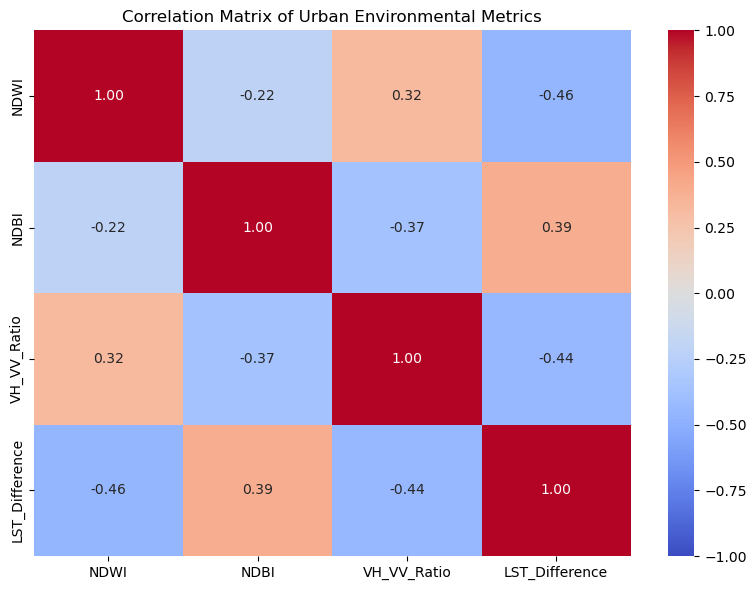


 2. VARIANCE INFLATION FACTOR (VIF) 
      Variable   VIF
3  VH_VV_Ratio  1.25
2         NDBI  1.18
1         NDWI  1.13


In [2]:
# =================================================================
# 2. Pearson's Correlation and VIF to verify no colinearity for Multiple Linear Regression
# =================================================================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

import pandas as pd
import numpy as np

# 2. Define your variables
df= pd.read_csv('Gangseo_Master_Cleaned.csv') #change name as appropriate

# LST is the target, the indices are the predictors
#I found NDWI and NDVI too highly correlated
#I picked NDWI due to the 'river' classification
predictors = ['NDWI', 'NDBI','VH_VV_Ratio']##can toggle between NDVI and NDWI, or other variables------------------------------------
all_vars = predictors + ['LST_Difference']

print("==================================================")
print(" 1. PEARSON CORRELATION MATRIX ")
print("==================================================")


# Ensure the 'Date' column is converted to datetime format
df['Date'] = pd.to_datetime(df['Date'])


# Calculate the correlation matrix
corr_matrix = df[all_vars].corr() #measures linear strength between all variables, TOGGLE HERE if want to see specific season
print(corr_matrix.round(3)) #prints within 3 digits

# Plot a heatmap for visual analysis
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, fmt=".2f")
plt.title('Correlation Matrix of Urban Environmental Metrics')
plt.tight_layout()
plt.savefig('total correlation analysis')
plt.show()

print("\n==================================================")
print(" 2. VARIANCE INFLATION FACTOR (VIF) ")
print("==================================================")

# Extract only the predictor variables for the VIF test
X = df[predictors]

# statsmodels requires a constant (intercept) to be added for the VIF math to work correctly
X_with_constant = add_constant(X)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Variable"] = X_with_constant.columns
vif_data["VIF"] = [variance_inflation_factor(X_with_constant.values, i) 
                   for i in range(X_with_constant.shape[1])]

# Drop the 'const' row from the printout because it doesn't mean anything for our analysis
vif_clean = vif_data[vif_data['Variable'] != 'const'].copy()

# Sort by highest VIF to immediately see the worst offenders-> VIF measures inflation due to colinearity 
vif_clean = vif_clean.sort_values(by='VIF', ascending=False)
print(vif_clean.round(2))


--- Generating Regional Correlation Heatmaps for ALL SEASONS ---


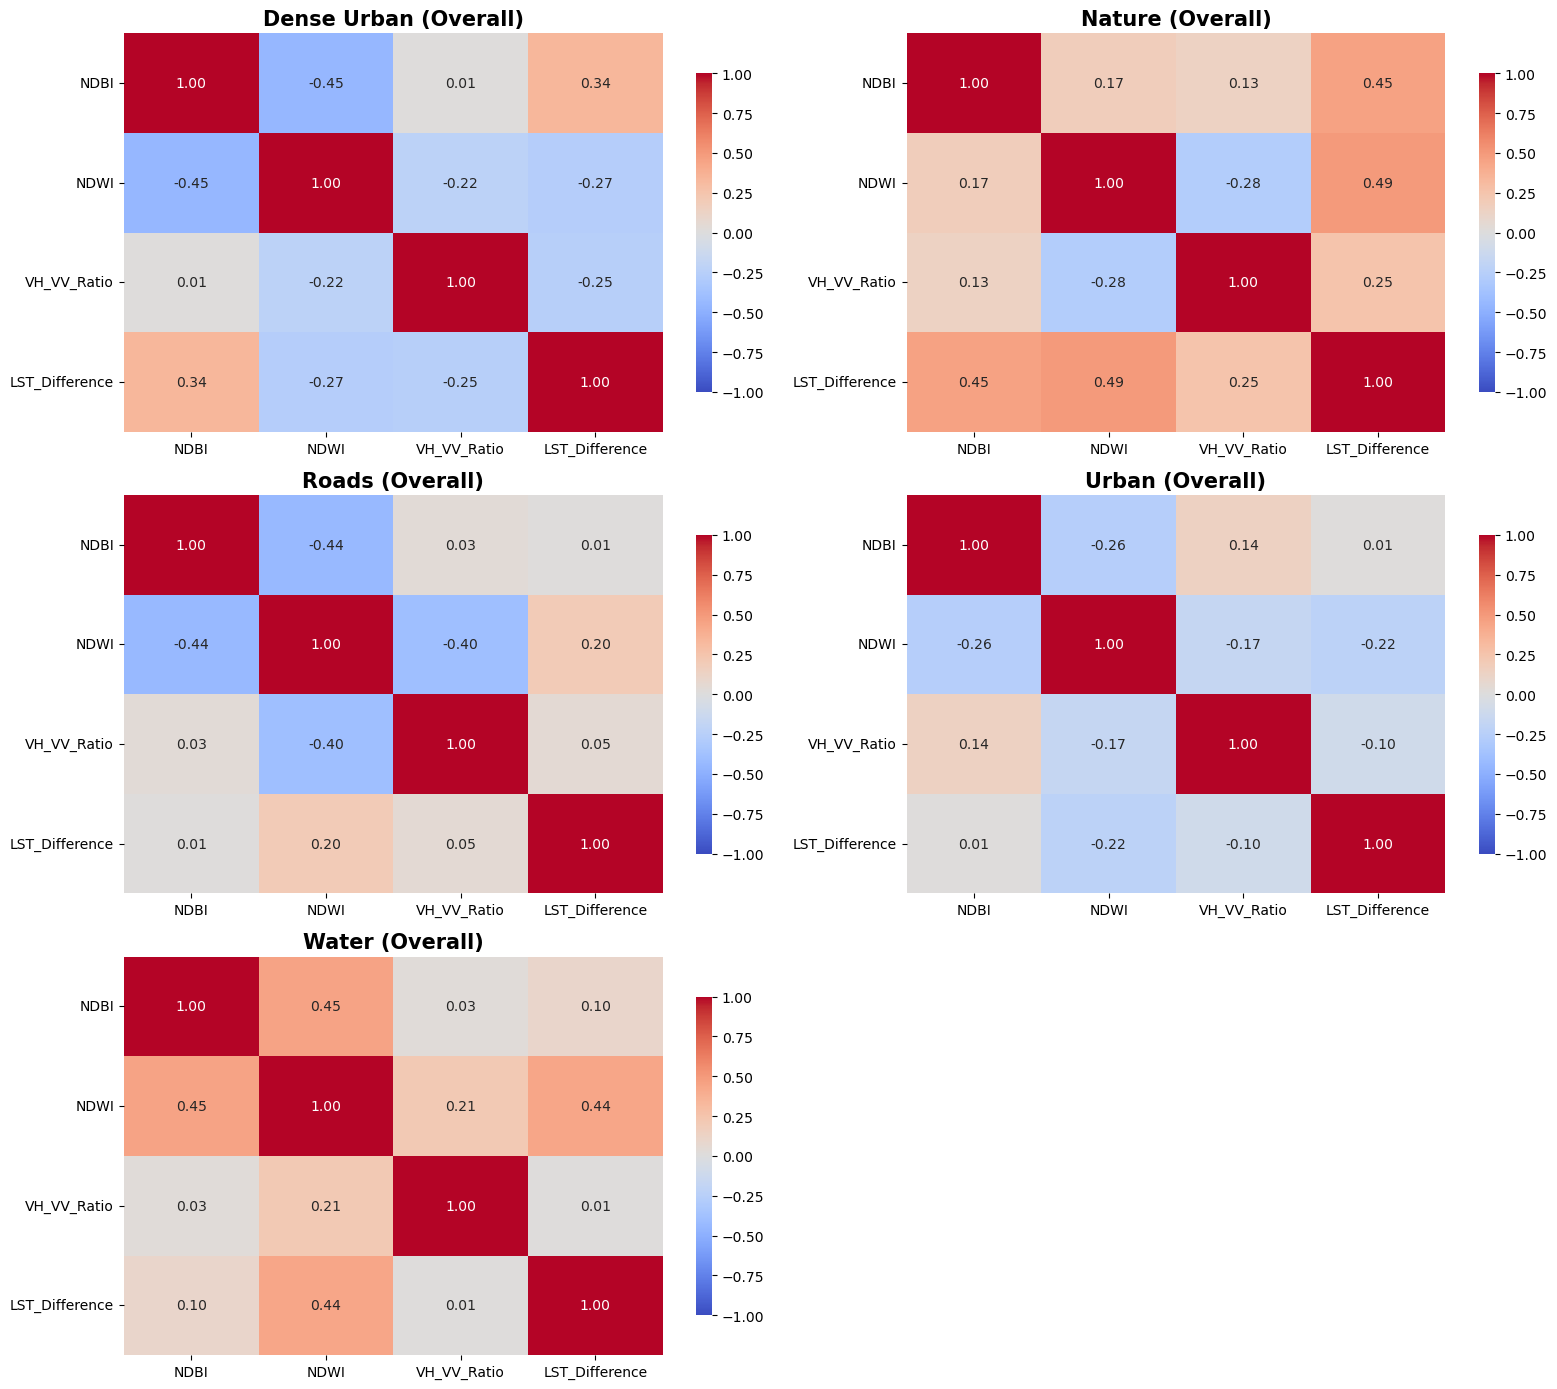

In [8]:
# =================================================================
# 2a. Stratified Correlations
# =================================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =====================================================================
# 1. THE SEASON TOGGLE
# Change this to 'Winter', 'Spring', 'Summer', 'Fall', or 'Overall'
# =====================================================================
CHOSEN_SEASON = 'Overall' 

# Create a safe working copy of the data
if CHOSEN_SEASON != 'Overall':
    working_df = df[df['Season'] == CHOSEN_SEASON].copy()
    print(f"\n--- Generating Regional Correlation Heatmaps for {CHOSEN_SEASON.upper()} ---")
else:
    working_df = df.copy()
    print("\n--- Generating Regional Correlation Heatmaps for ALL SEASONS ---")
# =====================================================================

# 2. Define the exact variables you want in the matrix
vars_to_correlate = ['NDBI', 'NDWI', 'VH_VV_Ratio', 'LST_Difference']

# Get the unique regions from our newly filtered working_df
unique_areas = working_df['Class'].dropna().unique()

# 3. Set up a 3x2 grid for the heatmaps (gives us 6 slots)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 14))
axes = axes.flatten() # Flatten to easily loop through the subplots

# 4. Loop through each area, calculate its specific correlation, and plot it
for i, area in enumerate(unique_areas):
    
    # Filter the dataframe for the specific area and isolate our variables
    area_df = working_df[working_df['Class'] == area][vars_to_correlate]
    
    # Safety net: Skip if there isn't enough data in this season to run correlations
    if len(area_df) < 2:
        print(f"Skipping {area} - not enough data for {CHOSEN_SEASON}")
        continue
    
    # Calculate the Pearson correlation matrix for this specific region
    corr_matrix = area_df.corr()
    
    # Plot the heatmap in the corresponding subplot
    sns.heatmap(
        corr_matrix, 
        annot=True,          # Show the numbers
        cmap='coolwarm',     # Red for positive, Blue for negative
        center=0,            # Center the color scale at 0
        vmin=-1, vmax=1,     # Lock the scale from -1 to 1 for visual consistency
        fmt=".2f",           # Round to 2 decimal places
        ax=axes[i],          # Place it in the correct grid slot
        cbar_kws={"shrink": 0.8} # Slightly shrink the color bar to fit nicely
    )
    
    # Add a bold title to each subplot that includes the chosen season!
    axes[i].set_title(f'{area} ({CHOSEN_SEASON})', fontsize=15, fontweight='bold')

# 5. Clean up extra empty plots
# Since we have 5 land classes but a 3x2 grid (6 slots), delete any unused empty boxes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout so nothing overlaps and display the plot
plt.tight_layout()
plt.show()

--- Generating Visuals for ALL SEASONS ---


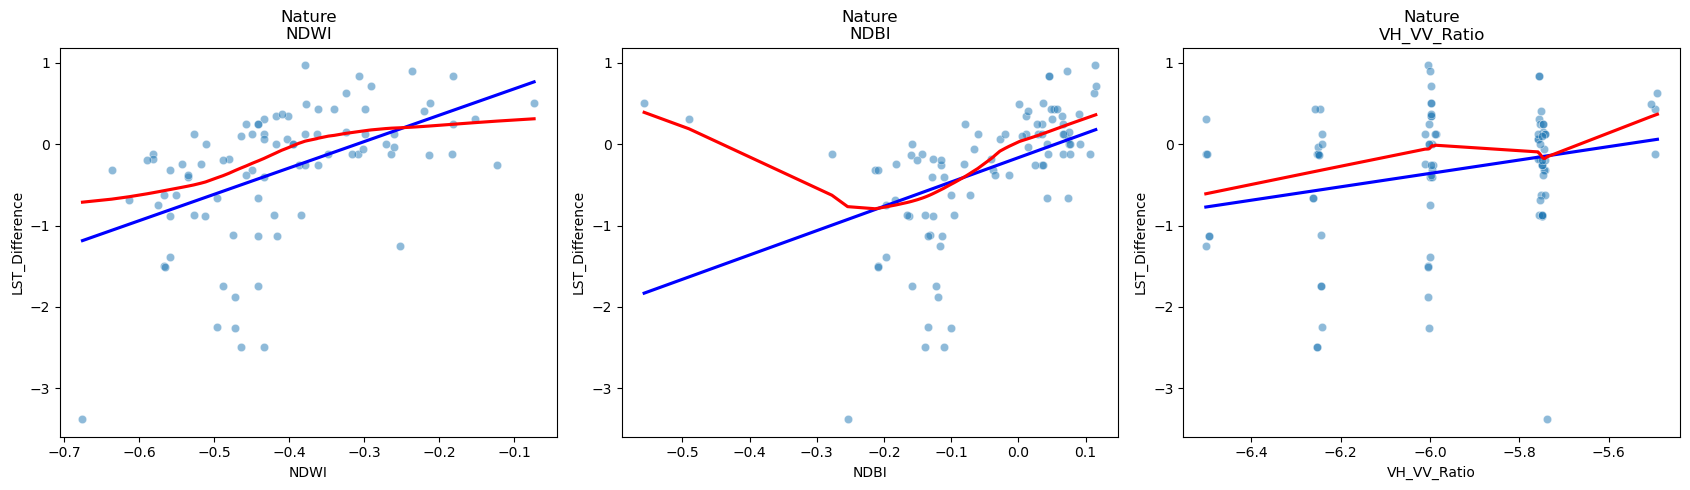

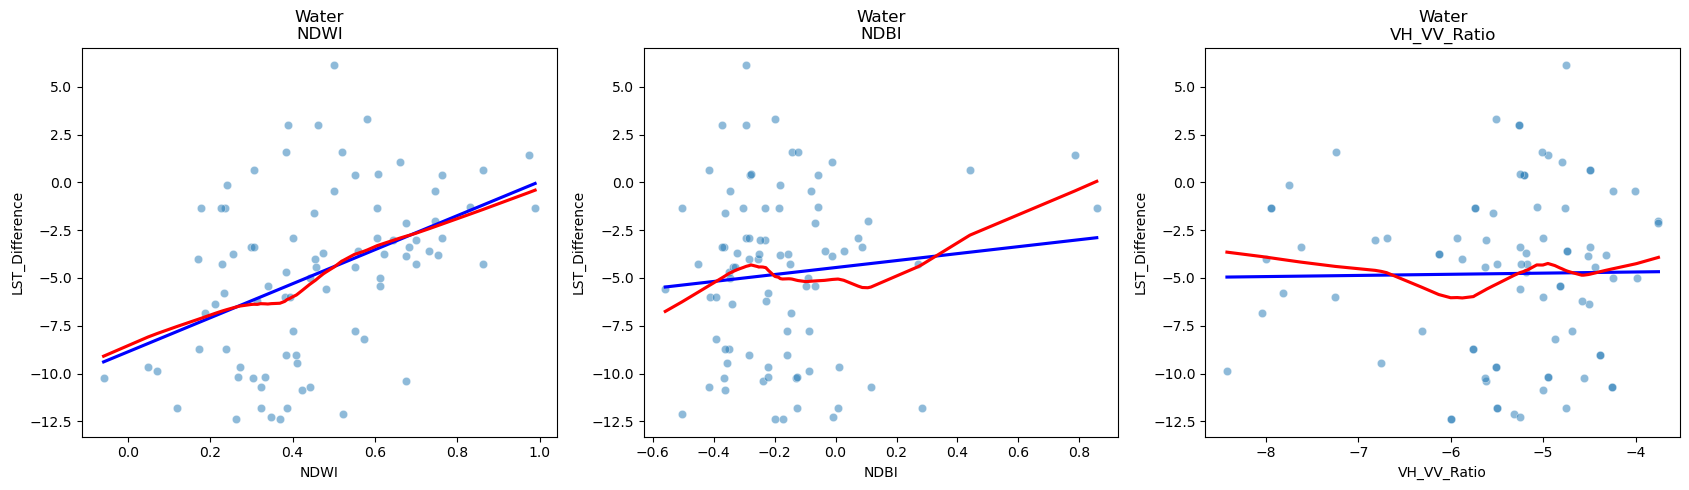

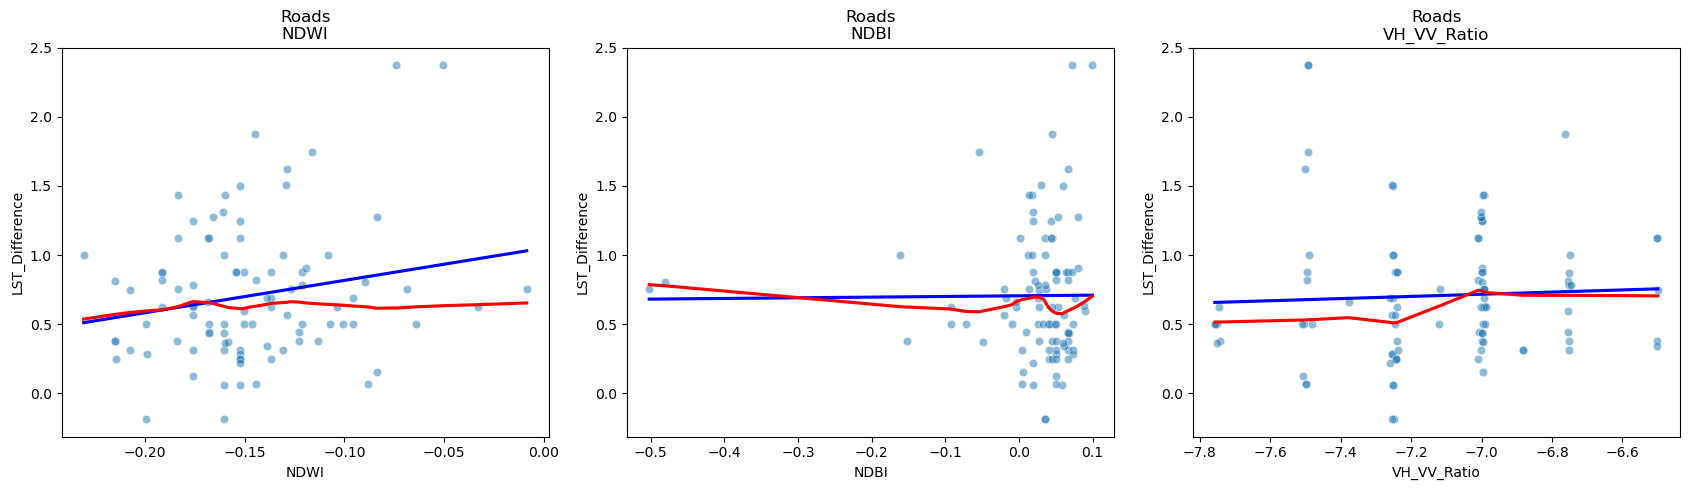

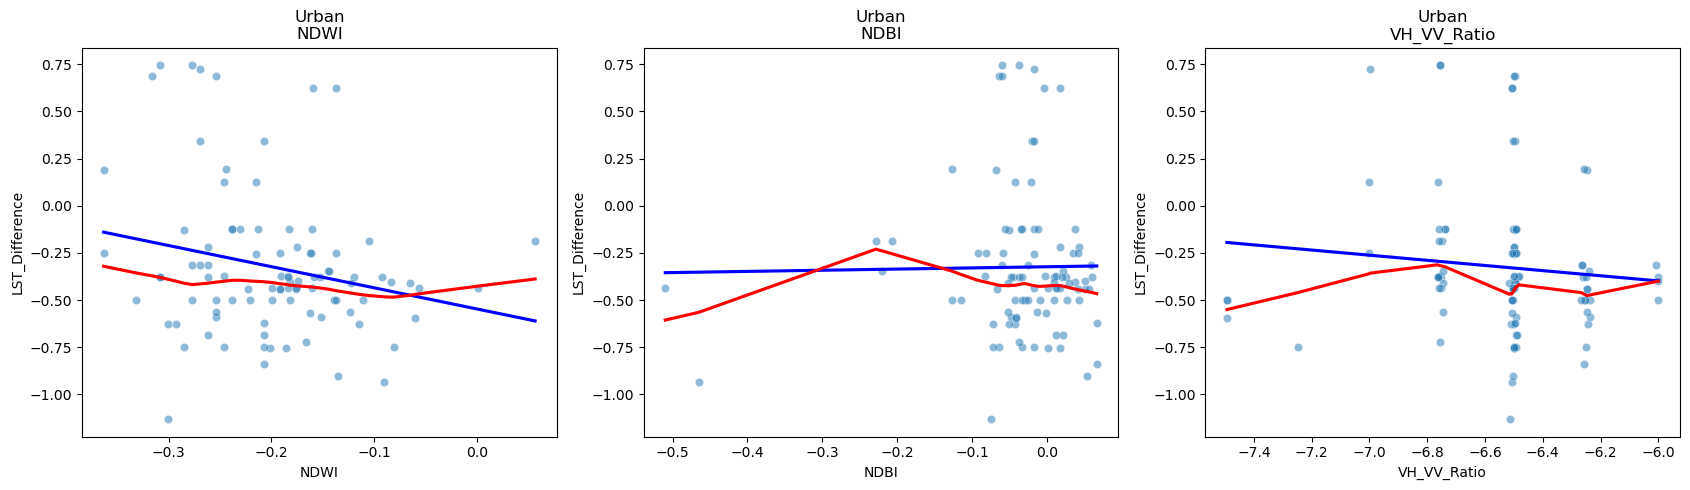

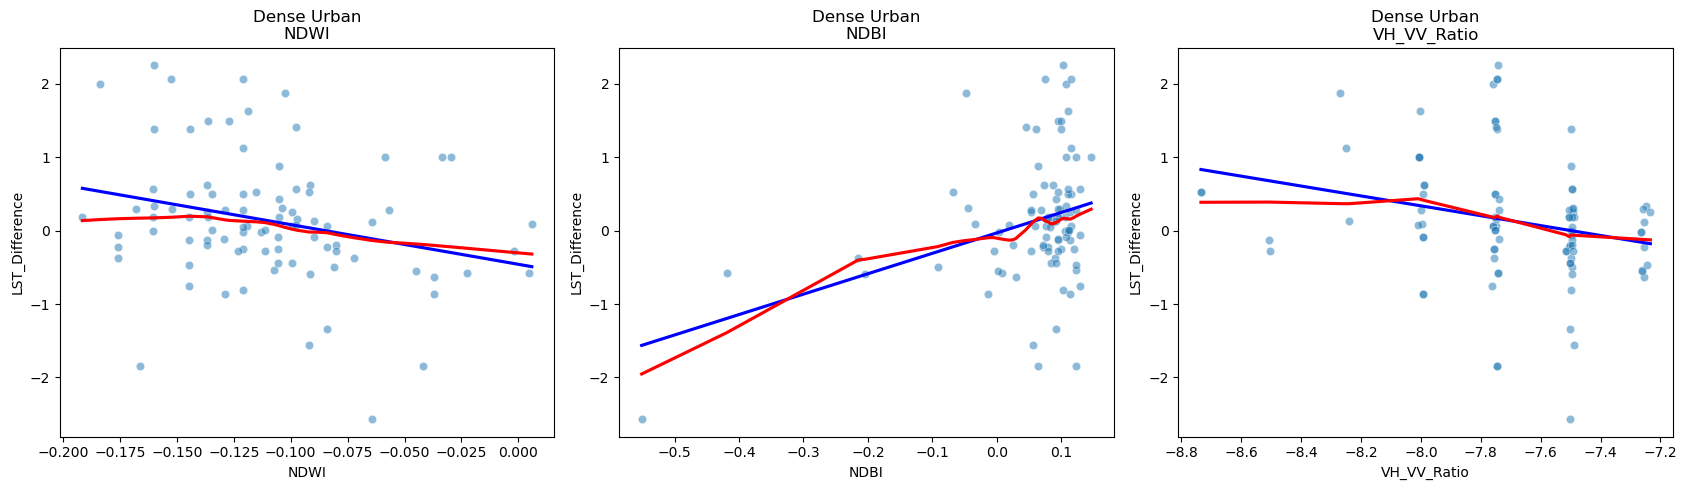

In [66]:
# =================================================================
# 2b. Visuals of Linearity - should be more linear for linear regression
# =================================================================
import seaborn as sns
import matplotlib.pyplot as plt

CHOSEN_SEASON = 'Overall' 

# Filter the dataframe based on your toggle
if CHOSEN_SEASON != 'Overall':
    working_df = df[df['Season'] == CHOSEN_SEASON].copy()
    print(f"--- Generating Visuals for {CHOSEN_SEASON.upper()} ---")
else:
    working_df = df.copy()
    print("--- Generating Visuals for ALL SEASONS ---")

landuses = ['Nature','Water','Roads','Urban','Dense Urban']
predictors = ['NDWI','NDBI','VH_VV_Ratio'] #use for your defined variables
for land in landuses:

    df_land = df[df['Class']==land]

    fig, axes = plt.subplots(1,3,figsize=(17,5))

    for ax, pred in zip(axes,predictors):#pairs up axes with the predictors

        # Scatter
        sns.scatterplot(#plots the data points
            data=df_land,
            x=pred,
            y='LST_Difference',
            alpha=0.5,
            ax=ax
        )

        # Linear regression
        sns.regplot(#plots a straight line through the data
            data=df_land,
            x=pred,
            y='LST_Difference',
            scatter=False,
            ci=None,
            color='blue',
            ax=ax
        )

        # LOWESS smoother
        sns.regplot(#plots the actual flow of the data (for linear regression, the closer to regression line the better)
            data=df_land,
            x=pred,
            y='LST_Difference',
            scatter=False,
            lowess=True,
            ci=None,
            color='red',
            ax=ax
        )

        ax.set_title(f'{land}\n{pred}')

    plt.tight_layout()
    plt.show()

In [68]:

# =================================================================
# 2c. Linear Validation of Regression (WITH SEASON TOGGLE & MAD OUTLIERS)
# =================================================================
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# =====================================================================
# 1. THE SEASON TOGGLE
# Change this to 'Winter', 'Spring', 'Summer', 'Fall', or 'Overall'
# =====================================================================
CHOSEN_SEASON = 'Overall' 

# Create a safe working copy of the data
if CHOSEN_SEASON != 'Overall':
    working_df = df[df['Season'] == CHOSEN_SEASON].copy()
    print(f"\n--- Running Linearity Check for {CHOSEN_SEASON.upper()} ---")
else:
    working_df = df.copy()
    print("\n--- Running Linearity Check for ALL SEASONS ---")

# =====================================================================
# 2. REMOVE MAD OUTLIERS (Creates a Cleaned Dataset)
# =====================================================================
def remove_mad_outliers(group):
    # Find the median of the temperature
    median = group["LST"].median()
    # Calculate the Median Absolute Deviation (MAD)
    mad = np.median(np.abs(group["LST"] - median))
    
    # Set the upper and lower limits
    threshold = median + 3 * mad
    lower = median - 3 * mad
    
    # RETURN ONLY THE GOOD DATA (Inside the limits)
    return group[(group["LST"] >= lower) & (group["LST"] <= threshold)]

# Apply the filter group-by-group so we can compare apples to apples
working_df_clean = (
    working_df.groupby(["Season", "Class"], group_keys=False)
    .apply(remove_mad_outliers)
)

# Print how much data was cleaned out
original_len = len(working_df)
clean_len = len(working_df_clean)
print(f"Data Cleaning: Removed {original_len - clean_len} extreme LST outliers.\n")

# =====================================================================
# 3. RUN THE REGRESSION MATH ON THE CLEANED DATA
# =====================================================================
# Variables
predictors = ["NDWI", "NDBI", "VH_VV_Ratio"]
classes = working_df_clean["Class"].dropna().unique()

results = []

# Loop through every land-use class
for landuse in classes:

    # Grab only the data for the current land use from the CLEAN dataset
    subset = working_df_clean[working_df_clean["Class"] == landuse].copy()
    
    # Safety net: Skip if there isn't enough data in this season to do math
    if len(subset) < 10:
        print(f"Skipping {landuse} - Not enough data for {CHOSEN_SEASON}")
        continue

    for predictor in predictors:

        # Create squared term (this lets us test for a "curve" in the data)
        subset[f"{predictor}_sq"] = subset[predictor]**2

        # -----------------------------
        # Linear model (Straight Line: y = mx + b)
        # -----------------------------
        linear = smf.ols(
            formula=f"LST ~ {predictor}",
            data=subset
        ).fit()

        # -----------------------------
        # Quadratic model (Curved Line: y = ax^2 + bx + c)
        # -----------------------------
        quadratic = smf.ols(
            formula=f"LST ~ {predictor} + {predictor}_sq",
            data=subset
        ).fit()

        results.append({
            "Land Use": landuse,
            "Predictor": predictor,

            "Linear Adj R²": linear.rsquared_adj,
            "Quadratic Adj R²": quadratic.rsquared_adj,
            "ΔAdj R²": quadratic.rsquared_adj - linear.rsquared_adj,

            "Linear AIC": linear.aic,
            "Quadratic AIC": quadratic.aic,
            "ΔAIC": quadratic.aic - linear.aic,

            "Linear BIC": linear.bic,
            "Quadratic BIC": quadratic.bic,

            "Quadratic p": quadratic.pvalues.get(f"{predictor}_sq", float('nan'))
        })

# Create results table
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(["Land Use", "Predictor"])

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

print(results_df.round(4))

# =====================================================================
# HOW TO INTERPRET THESE RESULTS (Cheat Sheet)
# =====================================================================
print("\n" + "="*70)
print(" 📊 HOW TO INTERPRET THIS TABLE:")
print("="*70)
print("This code tests if your data is LINEAR (straight) or NON-LINEAR (curved).")
print("It compares a standard Linear model to a Quadratic (curved) model.")
print("")
print("Look at the last 3 columns for each row (ΔAdj R², ΔAIC, Quadratic p):")
print("")
print("1. Quadratic p (The P-Value of the Curve):")
print("   - If p > 0.05: The curve is NOT statistically significant. Your data is")
print("                  LINEAR. Stick with a standard linear regression.")
print("   - If p < 0.05: The curve is statistically significant. Proceed to step 2.")
print("")
print("2. ΔAdj R² (Change in Accuracy):")
print("   - Even if p < 0.05, look at how much the curve actually helped.")
print("   - If ΔAdj R² is very small (e.g., 0.01), it means the curve only improved")
print("     the model by 1%. It's usually better to just keep it simple/linear.")
print("")
print("3. ΔAIC (Change in Efficiency):")
print("   - If ΔAIC is a POSITIVE number: The linear model is better.")
print("   - If ΔAIC is a NEGATIVE number: The curved model is better.")
print("     (A drop of -2 or more is considered a meaningful improvement).")
print("="*70 + "\n")


--- Running Linearity Check for ALL SEASONS ---
Data Cleaning: Removed 28 extreme LST outliers.

       Land Use    Predictor  Linear Adj R²  Quadratic Adj R²  ΔAdj R²  \
1   Dense Urban         NDBI         0.0180            0.0060  -0.0120   
0   Dense Urban         NDWI         0.0679            0.0603  -0.0077   
2   Dense Urban  VH_VV_Ratio         0.0223            0.0155  -0.0069   
4        Nature         NDBI         0.2208            0.3789   0.1581   
3        Nature         NDWI         0.1636            0.1799   0.0163   
5        Nature  VH_VV_Ratio        -0.0073           -0.0192  -0.0118   
7         Roads         NDBI        -0.0058            0.0005   0.0064   
6         Roads         NDWI         0.0133            0.0203   0.0070   
8         Roads  VH_VV_Ratio        -0.0041           -0.0097  -0.0056   
10        Urban         NDBI         0.0006            0.1382   0.1376   
9         Urban         NDWI         0.2328            0.2248  -0.0080   
11        Urba

/tmp/ipykernel_202/1989253877.py:43: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(remove_mad_outliers)


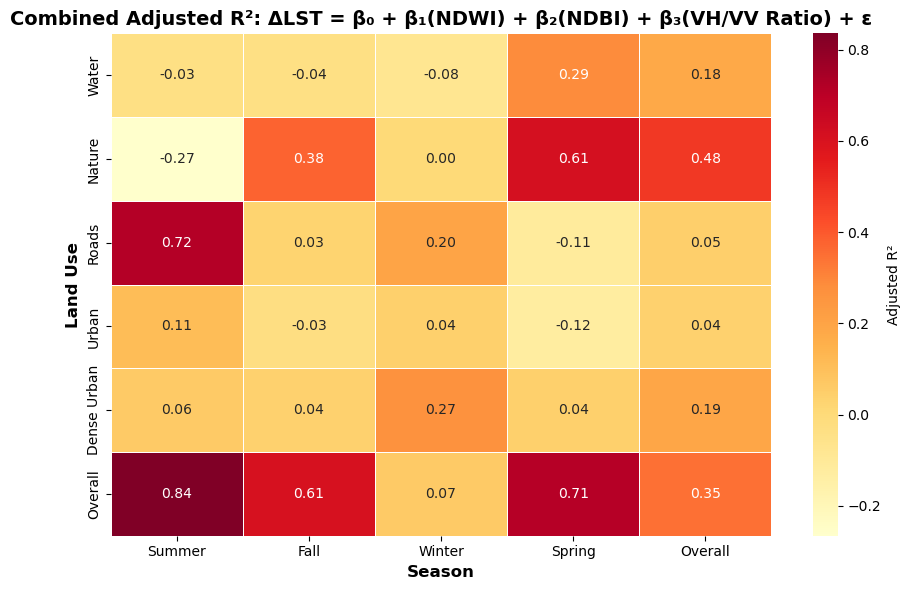

Season         Summer      Fall    Winter    Spring   Overall
Land Use                                                     
Water       -0.034946 -0.035308 -0.076490  0.286021  0.181575
Nature      -0.265205  0.378558  0.001699  0.612850  0.481307
Roads        0.719164  0.027402  0.200986 -0.113311  0.047244
Urban        0.109223 -0.026363  0.042159 -0.124076  0.038455
Dense Urban  0.063805  0.039580  0.265403  0.044366  0.192155
Overall      0.835870  0.607540  0.065342  0.714820  0.345767

--- NUMBER OF UNIQUE IMAGES PER SEASON ---
   Season  Image_Count
0    Fall           25
1  Spring           25
2  Summer           13
3  Winter           33

--- NUMBER OF DATA POINTS (ROWS) PER CLASS PER SEASON ---
Class   Dense Urban  Nature  Roads  Urban  Water
Season                                          
Fall             25      25     25     25     23
Spring           24      24     25     24     23
Summer           11       9     13     12      9
Winter           31      32     33     33

In [3]:
# =================================================================
# 3. Multiple Linear Regression (Adjusted R) and Image Counts
# =================================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# -----------------------------
# 1. Load the Cleaned Data
# -----------------------------
df = pd.read_csv("Gangseo_Master_Cleaned.csv")

# -----------------------------
# 2. Settings
# -----------------------------
predictors = ["NDWI", "NDBI", "VH_VV_Ratio"]

season_order = ["Summer", "Fall", "Winter", "Spring", "Overall"]
land_order = ["Water", "Nature", "Roads", "Urban", "Dense Urban", "Overall"]

rows = []

# -----------------------------
# 3. Calculate Combined Adjusted R²
# -----------------------------
for season in season_order:
    for land in land_order:

        subset = df.copy()

        # Filter by season
        if season != "Overall":
            subset = subset[subset["Season"] == season]

        # Filter by land use
        if land != "Overall":
            subset = subset[subset["Class"] == land]

        # Remove missing values
        subset = subset[predictors + ["LST_Difference"]].dropna()

        # Need more observations than predictors + 1
        if len(subset) > len(predictors) + 1:

            X = subset[predictors]
            y = subset["LST_Difference"]

            model = LinearRegression()
            model.fit(X, y)

            r2 = model.score(X, y)

            n = len(subset)
            p = len(predictors)

            adj_r2 = 1 - (1 - r2) * ((n - 1) / (n - p - 1))

        else:
            adj_r2 = np.nan

        rows.append([season, land, adj_r2])

# -----------------------------
# 4. Results Formatting
# -----------------------------
results = pd.DataFrame(
    rows,
    columns=["Season", "Land Use", "Adjusted_R2"]
)

results["Adjusted_R2"] = results["Adjusted_R2"].astype(float)

results["Season"] = pd.Categorical(
    results["Season"],
    categories=season_order,
    ordered=True
)

results["Land Use"] = pd.Categorical(
    results["Land Use"],
    categories=land_order,
    ordered=True
)

results = results.sort_values(["Season", "Land Use"])

# -----------------------------
# 5. Heatmap Generation
# -----------------------------
heat = results.pivot(
    index="Land Use",
    columns="Season",
    values="Adjusted_R2"
)

plt.figure(figsize=(9,6))

sns.heatmap(
    heat,
    annot=True,
    cmap="YlOrRd",
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Adjusted R²"}
)

plt.title(
    "Combined Adjusted R²: ΔLST = β₀ + β₁(NDWI) + β₂(NDBI) + β₃(VH/VV Ratio) + ε",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Season",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Land Use",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()
plt.show()
print(heat)

# =========================================================
# COUNT 1: Number of unique images per season
# =========================================================
print("\n--- NUMBER OF UNIQUE IMAGES PER SEASON ---")

image_counts = (
    df.groupby("Season")["Date"]
      .nunique()
      .reset_index(name="Image_Count")
)

print(image_counts)

# =========================================================
# COUNT 2: Number of data rows per Land Use per Season
# =========================================================
print("\n--- NUMBER OF DATA POINTS (ROWS) PER CLASS PER SEASON ---")

class_counts = (
    df.groupby(["Season", "Class"])
      .size()
      .reset_index(name="Row_Count")
)

class_counts_pivot = (
    class_counts
    .pivot(index="Season", columns="Class", values="Row_Count")
    .fillna(0)
    .astype(int)
)

print(class_counts_pivot)

--- Running Analysis for ALL SEASONS ---
Nature: 90 observations across 90 images
Water: 85 observations across 85 images
Roads: 96 observations across 96 images
Urban: 94 observations across 94 images
Dense Urban: 91 observations across 91 images
       Land Use               Predictors  N_Images   Max_VIF        R2  \
34  Dense Urban  NDWI, NDBI, VH_VV_Ratio        91  1.329684  0.219083   
33  Dense Urban        NDBI, VH_VV_Ratio        91  1.000186  0.179670   
32  Dense Urban        NDWI, VH_VV_Ratio        91  1.051051  0.173886   
31  Dense Urban               NDWI, NDBI        91  1.253174  0.131412   
29  Dense Urban                     NDBI        91  1.000000  0.114163   
28  Dense Urban                     NDWI        91  1.000000  0.072464   
30  Dense Urban              VH_VV_Ratio        91  1.000000  0.063158   
6        Nature  NDWI, NDBI, VH_VV_Ratio        90  1.141777  0.498791   
4        Nature        NDWI, VH_VV_Ratio        90  1.085223  0.408452   
3        Nat

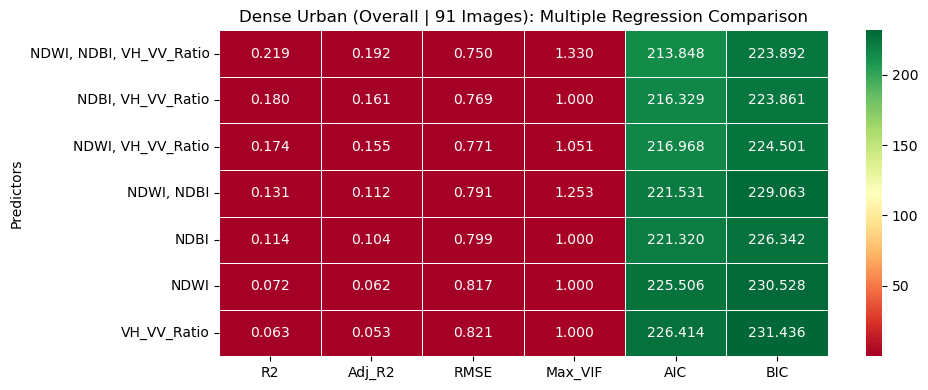

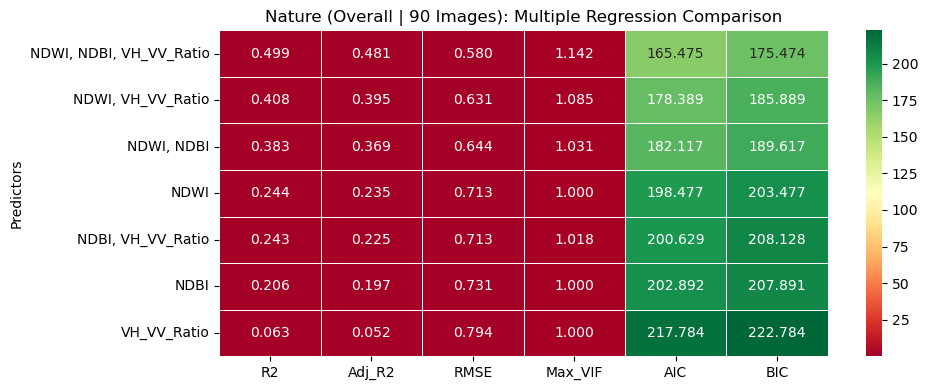

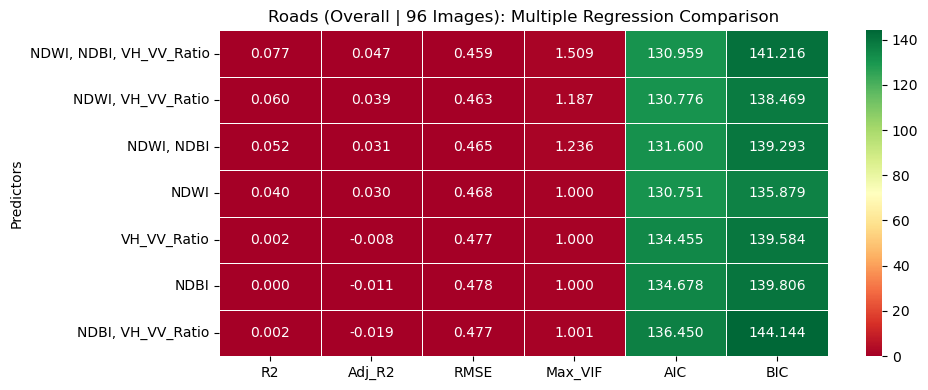

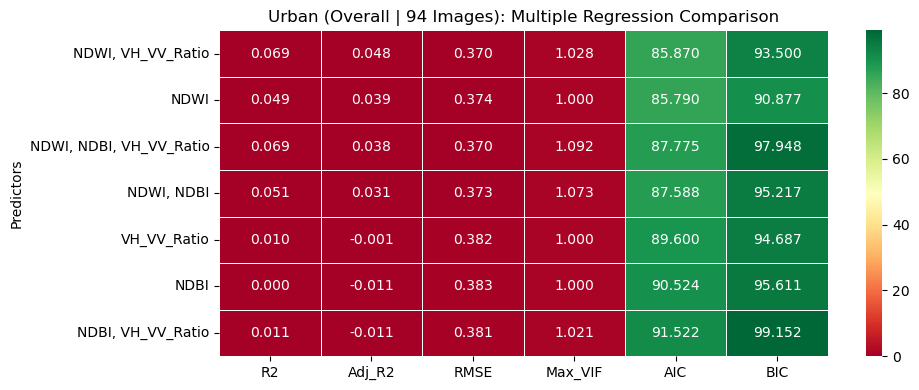

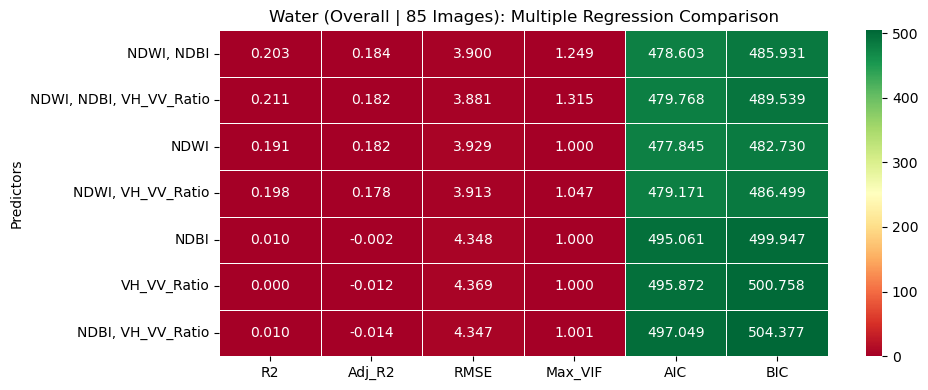

In [4]:
# =================================================================
# 3a. Multiple Linear Regression For Mulltiple Variables
# =================================================================
import statsmodels.api as sm
from itertools import combinations
from sklearn.metrics import mean_squared_error
from statsmodels.stats.outliers_influence import variance_inflation_factor # NEW IMPORT FOR VIF
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def assign_season(month):#numerical values to seasons
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Spring"
    elif month in [6,7,8]:
        return "Summer"
    else:
        return "Fall"

# 1. Apply the season mapping to your dataframe (if not already done)
# Assuming you have a 'Date' column:
df['Date'] = pd.to_datetime(df['Date'])
df['Season'] = df['Date'].dt.month.map(assign_season)

# =====================================================================
# THE SEASON TOGGLE
# Change this to 'Winter', 'Spring', 'Summer', 'Fall', or 'Overall'
# =====================================================================
CHOSEN_SEASON = 'Overall' 

if CHOSEN_SEASON != 'Overall':
    working_df = df[df['Season'] == CHOSEN_SEASON].copy()
    print(f"--- Running Analysis for {CHOSEN_SEASON.upper()} Only ---")
else:
    working_df = df.copy()
    print("--- Running Analysis for ALL SEASONS ---")
# =====================================================================

predictors = ['NDWI', 'NDBI', 'VH_VV_Ratio']
land_uses = ['Nature', 'Water', 'Roads', 'Urban', 'Dense Urban']

results = []

for land_use in land_uses:
    subset = working_df[working_df['Class'] == land_use].copy()
    
    # Calculate the exact number of unique images and total pixels
    n_images = subset['Date'].nunique()
    n_pixels = len(subset)

    print(f"{land_use}: {n_pixels} observations across {n_images} images")

    if len(subset) < 10: #skips anything with n<10
        print(f"Skipping {land_use} (Not enough data)")
        continue

    y = subset['LST_Difference']

    for r in range(1, len(predictors)+1):
        for combo in combinations(predictors, r):

            X = subset[list(combo)]
            X_with_const = sm.add_constant(X) # Statsmodels needs a constant

            model = sm.OLS(y, X_with_const).fit()
            predictions = model.predict(X_with_const)
            rmse = np.sqrt(mean_squared_error(y, predictions))

            # -----------------------------------------------------
            # CALCULATE MAX VIF FOR THIS COMBINATION
            # -----------------------------------------------------
            if r == 1:
                # If there's only 1 predictor, VIF is always 1.0 (no collinearity possible)
                max_vif = 1.0
            else:
                # Calculate VIF for each predictor in the combo and keep the highest one
                # We use range(1, X_with_const.shape[1]) to skip the constant column
                vifs = [variance_inflation_factor(X_with_const.values, i) 
                        for i in range(1, X_with_const.shape[1])]
                max_vif = max(vifs)
            # -----------------------------------------------------

            results.append({
                'Land Use': land_use,
                'Predictors': ', '.join(combo),
                'N_Images': n_images,          # ADDED IMAGE COUNT
                'Max_VIF': max_vif,            # ADDED MAX VIF
                'R2': model.rsquared,
                'Adj_R2': model.rsquared_adj,
                'RMSE': rmse,
                'AIC': model.aic,
                'BIC': model.bic
            })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    ['Land Use', 'Adj_R2'],
    ascending=[True, False]
)

print(results_df)

# =====================================================================
# GRAPHING
# =====================================================================
# ADDED Max_VIF to the metrics so it shows up as a column in your heatmap!
metrics = ['R2', 'Adj_R2', 'RMSE', 'Max_VIF', 'AIC', 'BIC']

for landuse in results_df['Land Use'].unique():

    plot_df = (
        results_df[results_df['Land Use'] == landuse]
        .set_index('Predictors')
    )

    # Grab the image count for the title
    img_count = plot_df['N_Images'].iloc[0]

    # Made the figure slightly wider (10,4) to accommodate the new VIF column
    plt.figure(figsize=(10,4))

    sns.heatmap(
        plot_df[metrics],
        annot=True,
        cmap='RdYlGn', # Green is good, Red is bad (NOTE: For VIF and AIC, lower is better, so the colors will reflect this dynamically)
        fmt=".3f",
        linewidths=0.5
    )

    # Added the Image Count (N) into the title for ultimate clarity
    plt.title(f"{landuse} ({CHOSEN_SEASON} | {img_count} Images): Multiple Regression Comparison")

    plt.tight_layout()
    plt.show()

Calculated Seasonal Medians: {'Summer': 36.689844657477586, 'Fall': 19.54902649703149, 'Winter': 3.72043965467087, 'Spring': 21.31161241989537}


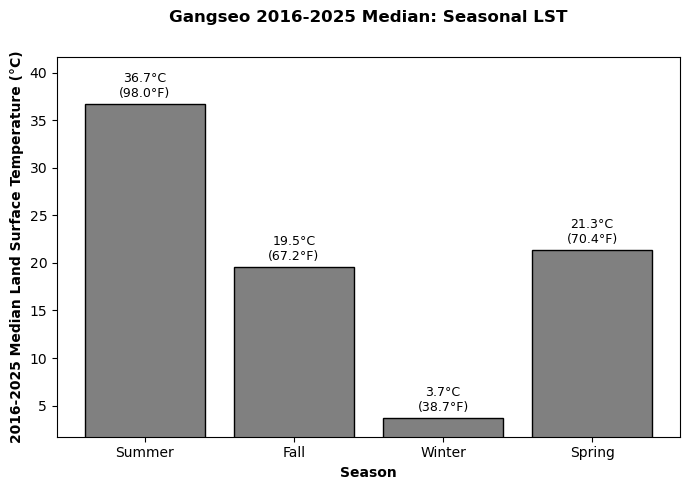

Seasonal LST median plot generated successfully!

--- Valid Image Counts by Season ---
Summer: 13 images
Fall: 25 images
Winter: 33 images
Spring: 25 images
Total Valid Images = 96

--- 2025 Data Check ---
Unique dates in 2025: 13


In [5]:
import matplotlib.pyplot as plt

# =====================================================================
# 4. Seasonal 10 Year LST Composite
# =====================================================================

# 1. Define the chronological order for the graph
season_order = ['Summer', 'Fall', 'Winter','Spring']

# 2. Calculate the median LST for each season directly from your main 'df'
LST_medians = {}
for season in season_order:
    # Filter for the season and find the median LST
    LST_medians[season] = df[df['Season'] == season]['LST'].median()

print("Calculated Seasonal Medians:", LST_medians)

# 3. Create figure and axis
fig, ax = plt.subplots(figsize=(7, 5))

# 4. Plot bars (I kept the grey color from your second command!)
bars = ax.bar(
    LST_medians.keys(),
    LST_medians.values(),
    color='grey',
    edgecolor='black'
)

# 5. Formatting
ax.set_title('Gangseo 2016-2025 Median: Seasonal LST', pad=25, fontweight='bold')
ax.set_xlabel('Season', fontweight='bold')
ax.set_ylabel('2016-2025 Median Land Surface Temperature (°C)', fontweight='bold')

# Gave the Y-axis more headroom so the Fahrenheit text doesn't get cut off
ax.set_ylim(
    min(LST_medians.values()) - 2,
    max(LST_medians.values()) + 5
)

# 6. Add dual Celsius & Fahrenheit labels directly above the bars
ax.bar_label(
    bars,
    labels=[f'{v:.1f}°C\n({v * 9/5 + 32:.1f}°F)' for v in LST_medians.values()],
    padding=3,
    fontsize=9
)

plt.tight_layout()
plt.savefig('seasonal_lst_medians.png', dpi=300)
plt.show()

print("Seasonal LST median plot generated successfully!\n")

# =====================================================================
# Image Counting & Date Checks
# =====================================================================
print("--- Valid Image Counts by Season ---")

total_images = 0
for season in season_order:
    # Count unique dates where LST is NOT missing (-9999)
    valid_dates = df[(df['Season'] == season) & (df['LST'] != -9999)]['Date'].nunique()
    print(f"{season}: {valid_dates} images")
    total_images += valid_dates

print(f"Total Valid Images = {total_images}\n")

# Check 2025 specifically
print("--- 2025 Data Check ---")
year2025 = df[df['Year'] == 2025]#can check any year here
print("Unique dates in 2025:", year2025['Date'].nunique())

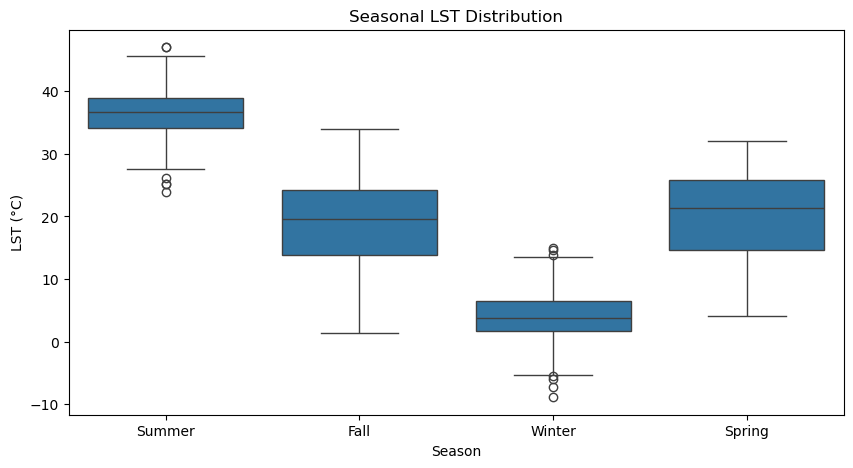

          Date        Class  Season        LST
344 2023-11-28  Dense Urban    Fall   1.345005
345 2023-11-28       Nature    Fall   2.032249
346 2023-11-28        Roads    Fall   2.031321
347 2023-11-28        Urban    Fall   1.345229
348 2023-11-28        Water    Fall   4.778625
1   2017-03-04       Nature  Spring  10.720458
308 2023-03-03       Nature  Spring  10.533469
168 2020-08-20  Dense Urban  Summer  34.096000
366 2024-08-09  Dense Urban  Summer  45.686386
371 2024-08-14  Dense Urban  Summer  45.686386
367 2024-08-09       Nature  Summer  42.941741
372 2024-08-14       Nature  Summer  42.941741
368 2024-08-09        Roads  Summer  47.061440
373 2024-08-14        Roads  Summer  47.061440
369 2024-08-09        Urban  Summer  45.315110
374 2024-08-14        Urban  Summer  45.315110
202 2021-01-07  Dense Urban  Winter  -8.907143
207 2021-02-26  Dense Urban  Winter  13.468582
203 2021-01-07       Nature  Winter  -6.031449
208 2021-02-26       Nature  Winter  14.906199
136 2020-02-2

/tmp/ipykernel_100/2682541567.py:64: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(mad_outliers)


In [6]:
# =================================================================
# 4a. Seasonal LST Graph Boxplot
# =================================================================
#quality control check
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df["Date"] = pd.to_datetime(df["Date"]) #these parts are redundant but ensure that this will run if block above not run 

df["Month"] = df["Date"].dt.month

def assign_season(month):#numerical values to seasons
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Spring"
    elif month in [6,7,8]:
        return "Summer"
    else:
        return "Fall"

df["Season"] = df["Month"].apply(assign_season)

plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="Season",
    y="LST",
    order=["Summer","Fall","Winter","Spring"]
)

plt.ylabel("LST (°C)")
plt.title("Seasonal LST Distribution")
plt.show()

import pandas as pd
import numpy as np

df["Season"] = df["Date"].dt.month.apply(assign_season)


# MAD outlier detection
def mad_outliers(group):

    median = group["LST"].median()

    mad = np.median(
        np.abs(group["LST"] - median)
    )#finds how much every value varies from median

    threshold = median + 3 * mad #3 times the median absolute deviation
    lower = median - 3 * mad

    return group[
        (group["LST"] < lower) |
        (group["LST"] > threshold)
    ]


outliers = (
    df.groupby(["Season","Class"], group_keys=False)
      .apply(mad_outliers)
)


print(outliers[
    ["Date","Class","Season","LST"]
])

--- Median LST Differences ---
        Nature  Water  Roads  Urban  Dense Urban
Summer   -1.75 -10.72   1.25   0.13         1.50
Fall     -0.31  -3.77   0.62  -0.38         0.19
Winter    0.12  -1.34   0.38  -0.44        -0.22
Spring   -0.13  -9.46   0.87  -0.40         0.03


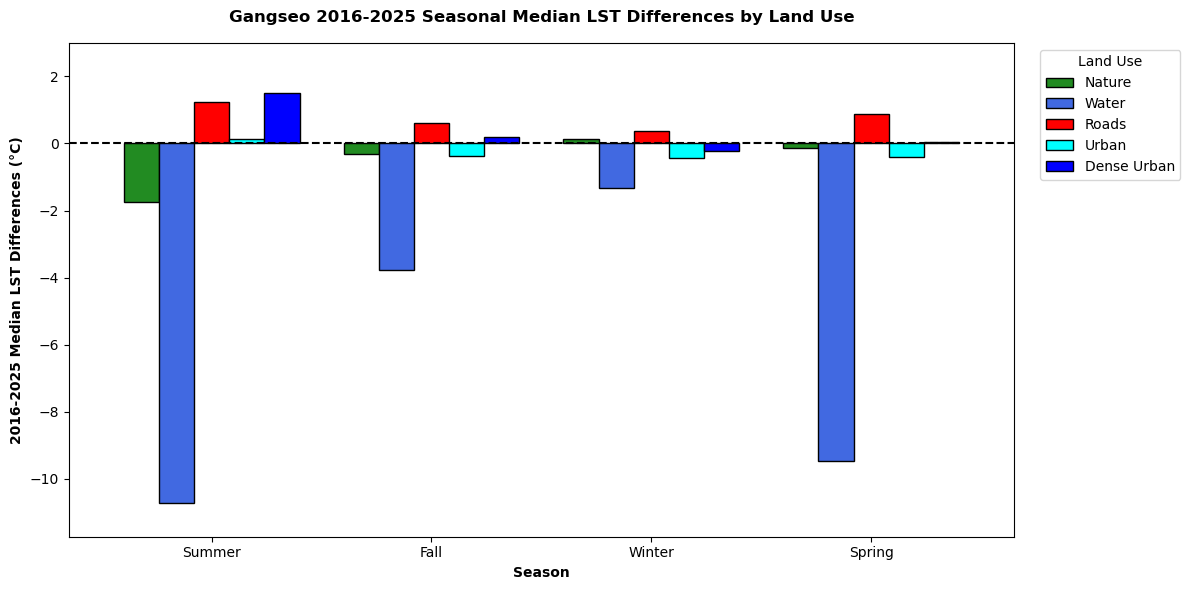

In [7]:
# =====================================================================
# 4b. LST Differences Stratified by Land Use
# =====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# 1. Define Categories
# =====================================================================
# Chronological order for the X-axis
season_names = ['Summer', 'Fall', 'Winter','Spring'] 

# Land classes, plus a new 'Overall City' category we will calculate!
classes = ['Nature', 'Water', 'Roads', 'Urban', 'Dense Urban']

# =====================================================================
# 2. Build the DataFrame using the main 'df'
# =====================================================================
plot_data = {}

for season in season_names:
    # Filter the main dataframe for this specific season
    season_data = df[df['Season'] == season]
    
    medians = {}
    
    # Calculate median for each land class
    for landuse in ['Nature', 'Water', 'Roads', 'Urban', 'Dense Urban']:
        medians[landuse] = season_data[season_data['Class'] == landuse]['LST_Difference'].median() #change to LST if want just that   
    plot_data[season] = medians

# Convert our calculations into a neat Pandas DataFrame
plot_df = pd.DataFrame(plot_data).T
plot_df = plot_df[classes] # Ensure the columns are in the correct order

print("--- Median LST Differences ---")
print(plot_df.round(2))

# =====================================================================
# 3. Graphing
# =====================================================================
# Colors (Mapped exactly to the 'classes' list above)
colors = [
    'forestgreen',    # Nature
    'royalblue',      # Water
    'red',            # Roads
    'cyan',           # Urban
    'blue',           # Dense Urban
]

fig, ax = plt.subplots(figsize=(12, 6))

# Create the grouped bar chart
bars = plot_df.plot(
    kind='bar',
    ax=ax,
    color=colors,
    edgecolor='black',
    width=0.8
)

# Add a dashed baseline at 0 (Neutral Temperature)
plt.axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=1.5
)

# Formatting
ax.set_ylabel("2016-2025 Median LST Differences (°C)", fontweight='bold')
ax.set_xlabel("Season", fontweight='bold')
ax.set_title("Gangseo 2016-2025 Seasonal Median LST Differences by Land Use", fontweight='bold', pad=15)

# Make x-axis labels horizontal
ax.tick_params(axis='x', rotation=0)

# Move the legend outside the plot so it doesn't cover any bars
ax.legend(
    title="Land Use",
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

# Add extra headroom so the labels don't get cut off at the top/bottom
plt.ylim(plot_df.min().min() - 1, plot_df.max().max() + 1.5)



plt.tight_layout()
plt.savefig('seasonal_landuse_lst_medians.png', dpi=300)
plt.show()

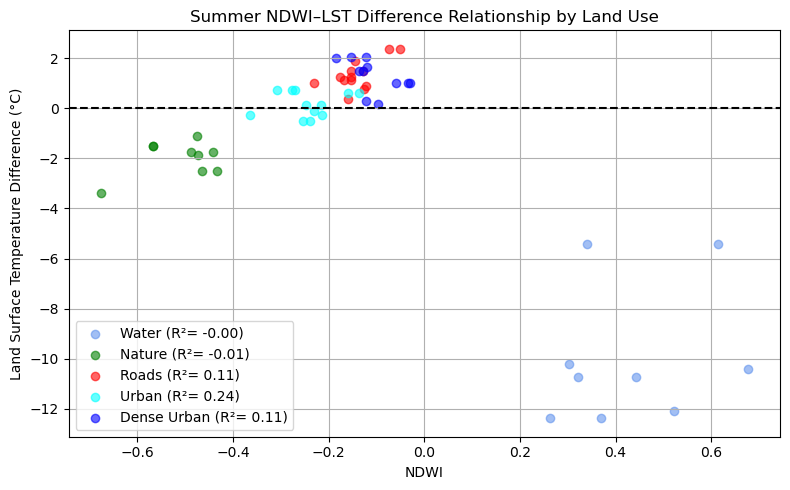

In [9]:
# =================================================================
# 5. NDWI LST_Difference Seasonal Scatterplot
# =================================================================

import matplotlib.pyplot as plt
import numpy as np
# Land use classes
classes = [
    "Water",
    "Nature",
    "Roads",
    "Urban",
    "Dense Urban",
]

# Custom colors
colors = {
    "Nature": "green",
    "Water": "cornflowerblue", 
    "Roads": "red",
    "Urban": "cyan",
    "Dense Urban": "blue"
}

def assign_season(month):#numerical values to seasons
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Spring"
    elif month in [6,7,8]:
        return "Summer"
    else:
        return "Fall"

# Filter Winter data 
winter_plot = df[(df["Season"] == "Summer")].dropna(subset=["NDWI", "LST_Difference", "Class"])#toggle seasons here

# Create plot
plt.figure(figsize=(8, 5))

for cls in classes:
    subset = winter_plot[winter_plot["Class"] == cls]
    
    if subset.empty:
        continue
        
    # 1. Scatter points
    plt.scatter(
        subset["NDWI"], 
        subset["LST_Difference"], 
        label=cls, 
        alpha=0.6, 
        color=colors[cls]
    )
    
# Labels and formatting
plt.xlabel("NDWI")
plt.ylabel("Land Surface Temperature Difference (°C)")
plt.title("Summer NDWI–LST Difference Relationship by Land Use")#change graph name as appropriate
plt.legend(["Water (R²= -0.00)", "Nature (R²= -0.01)", "Roads (R²= 0.11)", "Urban (R²= 0.24)", "Dense Urban (R²= 0.11)"])#must change manually
plt.grid(True)
plt.tight_layout()
# Horizontal reference line at y = 0
plt.axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=1.5
)
plt.savefig('Summer_NDWI_Graph.png', dpi=300) #Change PNG name
plt.show()

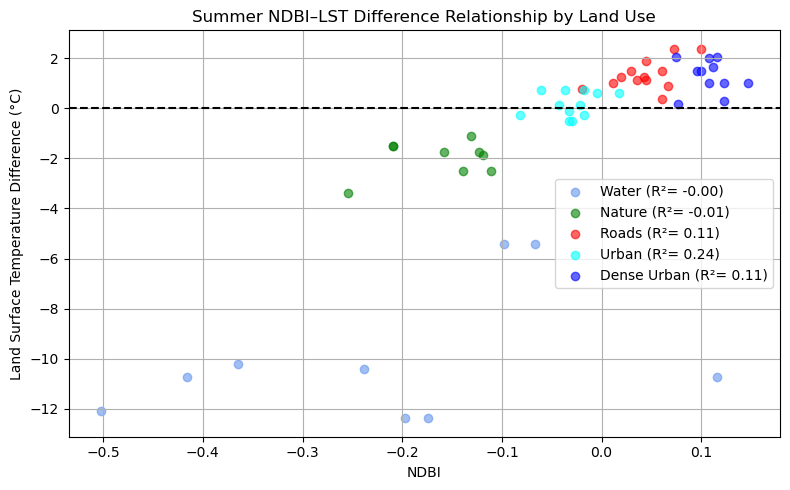

In [11]:
# =================================================================
# 6. NDBI LST_Difference Seasonal Scatterplot
# =================================================================

import matplotlib.pyplot as plt
import numpy as np
# Land use classes
classes = [
    "Water",
    "Nature",
    "Roads",
    "Urban",
    "Dense Urban",
]

# Custom colors
colors = {
    "Nature": "green",
    "Water": "cornflowerblue", 
    "Roads": "red",
    "Urban": "cyan",
    "Dense Urban": "blue"
}

def assign_season(month):#numerical values to seasons
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Spring"
    elif month in [6,7,8]:
        return "Summer"
    else:
        return "Fall"

# Filter data 
plot = df[(df["Season"] == "Summer")].dropna(subset=["NDBI", "LST_Difference", "Class"])#toggle seasons here

# Create plot
plt.figure(figsize=(8, 5))

for cls in classes:
    subset =plot[plot["Class"] == cls]
    
    if subset.empty:
        continue
        
    # 1. Scatter points
    plt.scatter(
        subset["NDBI"], 
        subset["LST_Difference"], 
        label=cls, 
        alpha=0.6, 
        color=colors[cls]
    )
    
# Labels and formatting
plt.xlabel("NDBI")
plt.ylabel("Land Surface Temperature Difference (°C)")
plt.title("Summer NDBI–LST Difference Relationship by Land Use") #change graph name as appropriate
plt.legend(["Water (R²= -0.00)", "Nature (R²= -0.01)", "Roads (R²= 0.11)", "Urban (R²= 0.24)", "Dense Urban (R²= 0.11)"])#must change manually
plt.grid(True)
plt.tight_layout()
# Horizontal reference line at y = 0
plt.axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=1.5
)
plt.savefig('Summer_NDBI_Graph.png', dpi=300) #change png name
plt.show()

In [12]:
# =================================================================
# 7. Overall Regression Results without Land Stratification
# =================================================================
import pandas as pd
import statsmodels.api as sm

# =====================================================================
# 1. THE SEASON TOGGLE
# Change this to 'Winter', 'Spring', 'Summer', 'Fall', or 'Overall'
# =====================================================================
CHOSEN_SEASON = 'Overall' 

# Create a safe working copy of the data
if CHOSEN_SEASON != 'Overall':
    working_df = df[df['Season'] == CHOSEN_SEASON].copy()
    print("==================================================")
    print(f" OVERALL CITY REGRESSION: {CHOSEN_SEASON.upper()} ")
    print("==================================================")
else:
    working_df = df.copy()
    print("==================================================")
    print(" OVERALL CITY REGRESSION: ALL SEASONS ")
    print("==================================================")
# =====================================================================

# SAFETY NET: Make sure there's enough data to run the math
if len(working_df) < 10:
    print(f"Error: Not enough data for {CHOSEN_SEASON} (n={len(working_df)})")
else:
    # Set up the variables for the entire chosen dataset (using working_df)
    # Note: Make sure 'predictors' is defined in a cell above this (e.g., predictors = ['NDWI', 'NDBI', 'VH_VV_Ratio'])
    X_global = working_df[predictors]
    X_global = sm.add_constant(X_global) # Add intercept
    y_global = working_df['LST_Difference']

    # Fit the Ordinary Least Squares (OLS) model for the whole city, filtering by date for 5 replicate land usages
    global_model = sm.OLS(y_global, X_global).fit(cov_type='cluster', cov_kwds={'groups': working_df['Date']})

    # Print a clean summary for the Global Model
    print(f"Total Sample Size (n): {len(working_df)}")
    print(f"Overall R-squared: {global_model.rsquared:.3f}")
    print("\nOverall Coefficients & Significance:")
    
    for var in X_global.columns:
        coef = global_model.params[var]
        p_val = global_model.pvalues[var]
        
        # Add asterisks for statistical significance
        if p_val < 0.01:
            significance = "***" 
        elif p_val < 0.05:
            significance = "**" 
        elif p_val < 0.1:
            significance = "*" 
        else:
            significance = "Not Sig."
            
        print(f"  {var:<12}: Coef = {coef:>6.3f} | p-value = {p_val:>5.4f} ({significance})")

print("-" * 50)

 OVERALL CITY REGRESSION: ALL SEASONS 
Total Sample Size (n): 456
Overall R-squared: 0.350

Overall Coefficients & Significance:
  const       : Coef = -5.693 | p-value = 0.0000 (***)
  NDWI        : Coef = -2.963 | p-value = 0.0000 (***)
  NDBI        : Coef =  4.005 | p-value = 0.0015 (***)
  VH_VV_Ratio : Coef = -0.718 | p-value = 0.0000 (***)
--------------------------------------------------


In [36]:
# =================================================================
# 7a. Stratified Regression Results by Land Usage
# =================================================================
import pandas as pd
import statsmodels.api as sm

# =====================================================================
# 1. THE SEASON TOGGLE
# Change this to 'Winter', 'Spring', 'Summer', 'Fall', or 'Overall'
# =====================================================================
CHOSEN_SEASON = 'Overall' 

# Create a safe working copy of the data
if CHOSEN_SEASON != 'Overall':
    working_df = df[df['Season'] == CHOSEN_SEASON].copy()
    print("==================================================")
    print(f" STRATIFIED REGRESSION RESULTS: {CHOSEN_SEASON.upper()} ")
    print("==================================================")
else:
    working_df = df.copy()
    print("==================================================")
    print(" STRATIFIED REGRESSION RESULTS: ALL SEASONS ")
    print("==================================================")
# =====================================================================

# Make sure your predictors are defined (adjust these if needed!)
predictors = ['NDWI', 'NDBI', 'VH_VV_Ratio']

# Get the unique land classes from the filtered dataset
unique_areas = working_df['Class'].dropna().unique()

for area in unique_areas:
    print(f"\n--- Regression Model for Area: {area} ({CHOSEN_SEASON}) ---")
    
    # Filter the dataset for just this specific area within the chosen season
    area_df = working_df[working_df['Class'] == area].copy()
    
    # SAFETY NET: OLS regression will crash if you don't have enough data points
    if len(area_df) < 10:
        print(f"Skipping {area} - Not enough data for robust regression (n={len(area_df)})")
        print("-" * 50)
        continue
    
    X = area_df[predictors]
    X = sm.add_constant(X) # Add intercept
    y = area_df['LST_Difference']
    
    # Fit the Ordinary Least Squares (OLS) model
    model = sm.OLS(y, X).fit()
    
    # Print a clean summary of the key metrics
    print(f"Sample Size (n): {len(area_df)}")
    print(f"R-squared: {model.rsquared:.3f}")
    print("\nCoefficients & Significance:")
    
    # Extract coefficients and p-values for a clean display
    for var in X.columns:
        coef = model.params[var]
        p_val = model.pvalues[var]
        
        # Add asterisks for statistical significance
        if p_val < 0.01:
            significance = "***" 
        elif p_val < 0.05:
            significance = "**" 
        elif p_val < 0.1:
            significance = "*" 
        else:
            significance = "Not Sig."
            
        print(f"  {var:<12}: Coef = {coef:>6.3f} | p-value = {p_val:>5.4f} ({significance})")
        
    print("-" * 50)

 STRATIFIED REGRESSION RESULTS: ALL SEASONS 

--- Regression Model for Area: Dense Urban (Overall) ---
Sample Size (n): 91
R-squared: 0.219

Coefficients & Significance:
  const       : Coef = -6.781 | p-value = 0.0016 (***)
  NDWI        : Coef = -4.597 | p-value = 0.0390 (**)
  NDBI        : Coef =  1.969 | p-value = 0.0274 (**)
  VH_VV_Ratio : Coef = -0.818 | p-value = 0.0024 (***)
--------------------------------------------------

--- Regression Model for Area: Nature (Overall) ---
Sample Size (n): 90
R-squared: 0.499

Coefficients & Significance:
  const       : Coef =  8.298 | p-value = 0.0000 (***)
  NDWI        : Coef =  3.549 | p-value = 0.0000 (***)
  NDBI        : Coef =  2.052 | p-value = 0.0002 (***)
  VH_VV_Ratio : Coef =  1.184 | p-value = 0.0000 (***)
--------------------------------------------------

--- Regression Model for Area: Roads (Overall) ---
Sample Size (n): 96
R-squared: 0.077

Coefficients & Significance:
  const       : Coef =  3.294 | p-value = 0.0179 (*

    Season     Land Use  Spearman_rho   p_value   N
0   Summer       Nature      0.138086  0.723125   9
1   Summer        Water     -0.439138  0.236977   9
2   Summer        Roads      0.394737  0.181934  13
3   Summer        Urban      0.245881  0.441100  12
4   Summer  Dense Urban      0.101827  0.765772  11
8     Fall        Urban     -0.181899  0.384177  25
7     Fall        Roads     -0.053139  0.800832  25
9     Fall  Dense Urban     -0.341317  0.094962  25
5     Fall       Nature     -0.029976  0.886892  25
6     Fall        Water     -0.356995  0.094478  23
10  Winter       Nature     -0.217008  0.232861  32
11  Winter        Water     -0.057626  0.762294  30
12  Winter        Roads      0.319255  0.070142  33
13  Winter        Urban      0.108919  0.546264  33
14  Winter  Dense Urban      0.101571  0.586653  31
18  Spring        Urban      0.305289  0.146874  24
15  Spring       Nature      0.032506  0.880145  24
16  Spring        Water      0.478577  0.020881  23
17  Spring  

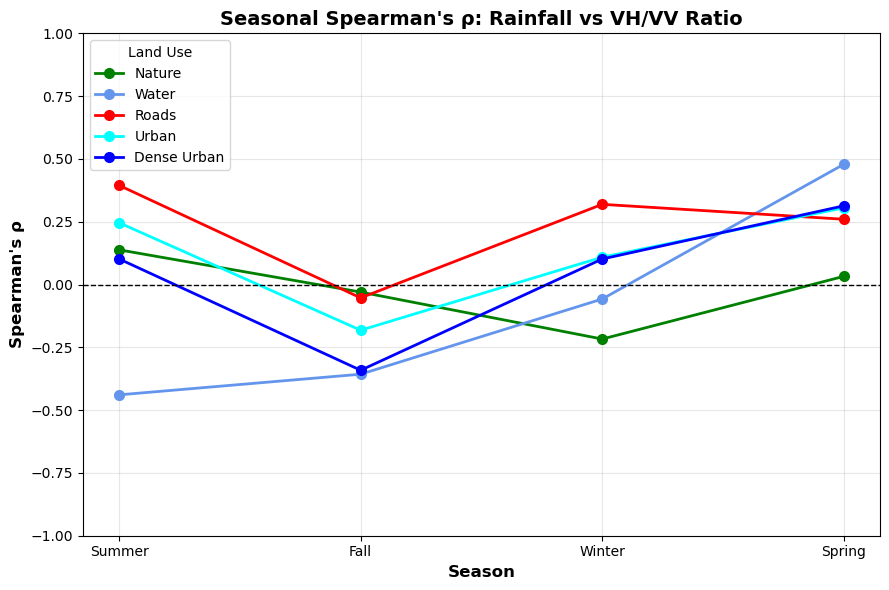

      Land Use     Variable  Spearman_rho   p_value   N
0        Water         NDWI      0.133116  0.224554  85
1        Water  VH/VV Ratio     -0.035146  0.749478  85
2       Nature         NDWI      0.004137  0.969131  90
3       Nature  VH/VV Ratio     -0.043290  0.685378  90
4        Roads         NDWI     -0.097552  0.344381  96
5        Roads  VH/VV Ratio      0.185235  0.070789  96
6        Urban         NDWI     -0.048434  0.642955  94
7        Urban  VH/VV Ratio      0.033224  0.750562  94
8  Dense Urban         NDWI     -0.093462  0.378220  91
9  Dense Urban  VH/VV Ratio      0.008796  0.934048  91


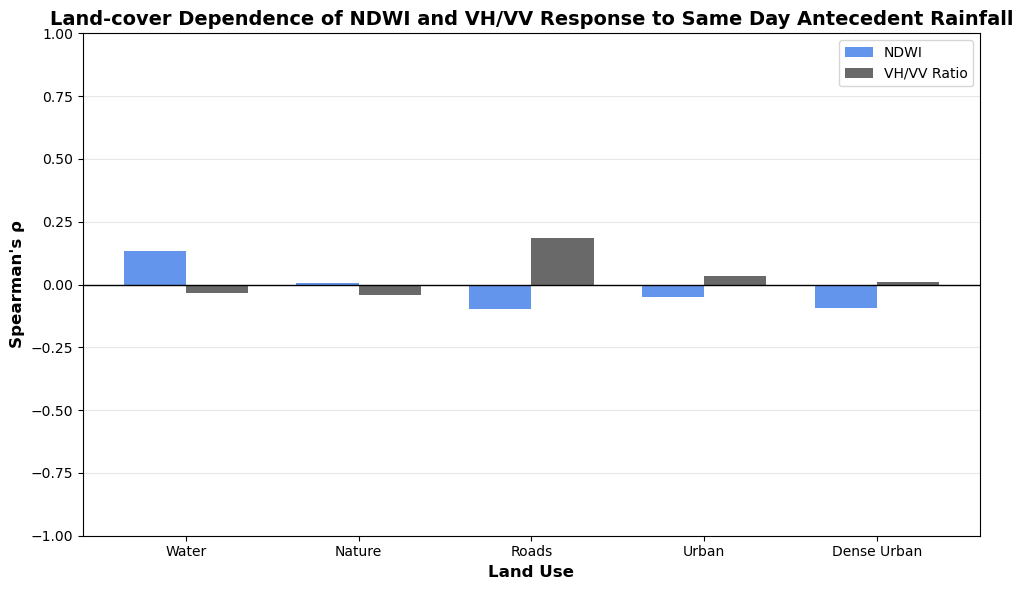

In [13]:
# =====================================================================
# 8. Sentinel 1 Exploratory Graphs (Rho and VH/VV values, Rainfall vs NDWI and VH/VV)
# =====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# ==========================================================
# 1. Load Data
# ==========================================================

df = pd.read_csv("Gangseo_Master_Cleaned.csv")
rain = pd.read_csv("/home/jovyan/Seoul_Precipitation.csv")

# ==========================================================
# 2. Convert dates
# ==========================================================

df["Date"] = pd.to_datetime(df["Date"])
rain["DATE"] = pd.to_datetime(rain["DATE"])

# ==========================================================
# 3. Clean rainfall
# ==========================================================

rain["PRCP"] = pd.to_numeric(rain["PRCP"], errors="coerce")
rain["PRCP"] = rain["PRCP"].fillna(0)
rain = rain.sort_values("DATE")

# ==========================================================
# 4. Calculate 1-day antecedent rainfall
# ==========================================================

rain_lookup = {}

for date in df["Date"].drop_duplicates():

    window = rain[
        (rain["DATE"] >= date - pd.Timedelta(days=1)) &
        (rain["DATE"] < date)#ensures it is the day before so Sentinel 1 is capturing it at 6am (overpass time)
    ]

    rain_lookup[date] = window["PRCP"].sum()

df["Rain_Day_Median"] = df["Date"].map(rain_lookup)

# ==========================================================
# 5. Settings
# ==========================================================

season_order = ["Summer", "Fall", "Winter", "Spring"]

land_order = [
    "Nature",
    "Water",
    "Roads",
    "Urban",
    "Dense Urban"
]

colors = {
    "Nature": "green",
    "Water": "cornflowerblue",
    "Roads": "red",
    "Urban": "cyan",
    "Dense Urban": "blue"
}

variable = "VH_VV_Ratio"

# ==========================================================
# 6. Calculate Spearman rho- better for rainfall data since not Normally distributed
# ==========================================================

rows = []

for season in season_order:

    for land in land_order:#together loops through each land usage and season

        subset = df[
            (df["Season"] == season) &
            (df["Class"] == land)
        ]

        temp = subset[
            ["Rain_Day_Median", variable]
        ].dropna()

        if len(temp) >= 3: #need at least 3 data points

            rho, p = spearmanr(
                temp["Rain_Day_Median"],
                temp[variable]
            )

        else:

            rho = np.nan
            p = np.nan

        rows.append({
            "Season": season,
            "Land Use": land,
            "Spearman_rho": rho,
            "p_value": p,
            "N": len(temp)
        })

results = pd.DataFrame(rows)

results["Season"] = pd.Categorical(
    results["Season"],
    categories=season_order,
    ordered=True
)

results = results.sort_values("Season")

print(results)

# Optional: save table
results.to_csv(
    "Seasonal_VHVV_Spearman.csv",
    index=False
)

# ==========================================================
# 7. Plot
# ==========================================================

plt.figure(figsize=(9,6))

for land in land_order:

    subset = results[
        results["Land Use"] == land
    ]

    plt.plot(
        subset["Season"],
        subset["Spearman_rho"],
        marker="o",
        linewidth=2,
        markersize=7,
        label=land,
        color=colors[land]
    )

plt.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.title(
    "Seasonal Spearman's ρ: Rainfall vs VH/VV Ratio",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Season",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Spearman's ρ",
    fontsize=12,
    fontweight="bold"
)

plt.ylim(-1,1)

plt.grid(alpha=0.3)

plt.legend(title="Land Use")

plt.tight_layout()

plt.show()

#ndwi and vh/vv response to short term below 

# ==========================================================
# 5. Settings
# ==========================================================

land_order = [
    "Water",
    "Nature",
    "Roads",
    "Urban",
    "Dense Urban"
]

variables = {
    "NDWI": "NDWI",
    "VH/VV Ratio": "VH_VV_Ratio"
}

rows = []

# ==========================================================
# 6. Calculate Overall Spearman Correlations
# ==========================================================

for land in land_order:

    subset = df[df["Class"] == land]

    for label, var in variables.items():

        temp = subset[["Rain_Day_Median", var]].dropna()

        if len(temp) >= 3:
            rho, p = spearmanr(
                temp["Rain_Day_Median"],
                temp[var]
            )
        else:
            rho = np.nan
            p = np.nan

        rows.append({
            "Land Use": land,
            "Variable": label,
            "Spearman_rho": rho,
            "p_value": p,
            "N": len(temp)
        })

results = pd.DataFrame(rows)

print(results)

results.to_csv(
    "Rainfall_LandUse_Spearman.csv",
    index=False
)

# ==========================================================
# 7. Grouped Bar Chart
# ==========================================================

pivot = results.pivot(
    index="Land Use",
    columns="Variable",
    values="Spearman_rho"
)

pivot = pivot.loc[land_order]

fig, ax = plt.subplots(figsize=(10,6))

x = np.arange(len(land_order))
width = 0.36

bars1 = ax.bar(
    x - width/2,
    pivot["NDWI"],
    width,
    color="cornflowerblue",
    label="NDWI"
)

bars2 = ax.bar(
    x + width/2,
    pivot["VH/VV Ratio"],
    width,
    color="dimgray",
    label="VH/VV Ratio"
)

# --------------------------------------------------
# Annotate significant correlations
# --------------------------------------------------

for i, row in results.iterrows():

    if row["p_value"] < 0.05:

        land_index = land_order.index(row["Land Use"])

        if row["Variable"] == "NDWI":
            xpos = land_index - width/2
        else:
            xpos = land_index + width/2

        ax.text(
            xpos,
            row["Spearman_rho"] +
            (0.04 if row["Spearman_rho"] >= 0 else -0.08),
            "*",
            ha="center",
            fontsize=18,
            fontweight="bold"
        )

# --------------------------------------------------

ax.axhline(
    0,
    color="black",
    linewidth=1
)

ax.set_xticks(x)
ax.set_xticklabels(land_order)

ax.set_ylim(-1,1)

ax.set_ylabel(
    "Spearman's ρ",
    fontsize=12,
    fontweight="bold"
)

ax.set_xlabel(
    "Land Use",
    fontsize=12,
    fontweight="bold"
)

ax.set_title(
    "Land-cover Dependence of NDWI and VH/VV Response to Same Day Antecedent Rainfall",
    fontsize=14,
    fontweight="bold"
)

ax.legend()

ax.grid(axis="y", alpha=0.3)

plt.tight_layout()


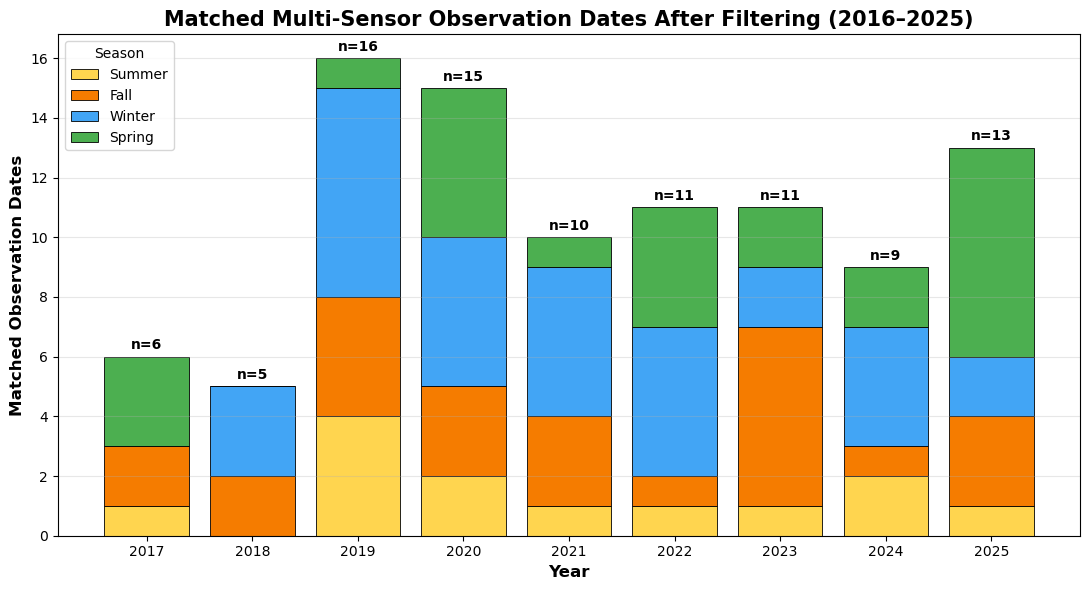


Matched Observation Dates by Year and Season

Season  Summer  Fall  Winter  Spring
Year                                
2017         1     2       0       3
2018         0     2       3       0
2019         4     4       7       1
2020         2     3       5       5
2021         1     3       5       1
2022         1     1       5       4
2023         1     6       2       2
2024         2     1       4       2
2025         1     3       2       7

Total matched observation dates: 96


In [14]:
# =================================================================
# 9. Annual Image Count by Season Graph
# =================================================================

import pandas as pd
import matplotlib.pyplot as plt

# ==========================================================
# Load data
# ==========================================================

df = pd.read_csv("Gangseo_Master_Cleaned.csv")

df["Date"] = pd.to_datetime(df["Date"])

# Remove any accidental spaces
df["Season"] = df["Season"].str.strip()

# ==========================================================
# One observation per matched date
# ==========================================================

dates = (
    df[["Date", "Year", "Season"]]
    .drop_duplicates(subset="Date")
)

# ==========================================================
# Count observation dates
# ==========================================================

season_order = ["Summer", "Fall", "Winter","Spring"]

counts = (
    dates.groupby(["Year", "Season"])
         .size()
         .unstack(fill_value=0)
)

# Ensure every season exists
counts = counts.reindex(columns=season_order, fill_value=0)

# ==========================================================
# Colors
# ==========================================================

colors = {
    "Spring": "#4CAF50",
    "Summer": "#FFD54F",
    "Fall": "#F57C00",
    "Winter": "#42A5F5"
}

# ==========================================================
# Plot
# ==========================================================

fig, ax = plt.subplots(figsize=(11,6))

bottom = [0] * len(counts)

for season in season_order:

    ax.bar(
        counts.index.astype(str),
        counts[season],
        bottom=bottom,
        color=colors[season],
        edgecolor="black",
        linewidth=0.6,
        label=season
    )

    bottom = [b + c for b, c in zip(bottom, counts[season])]

# ==========================================================
# Add total n labels
# ==========================================================

totals = counts.sum(axis=1)

for i, total in enumerate(totals):

    ax.text(
        i,
        total + 0.15,
        f"n={int(total)}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# ==========================================================
# Formatting
# ==========================================================

ax.set_title(
    "Matched Multi-Sensor Observation Dates After Filtering (2016–2025)",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Year", fontsize=12, fontweight="bold")
ax.set_ylabel("Matched Observation Dates", fontsize=12, fontweight="bold")

ax.legend(title="Season")

ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================================
# Print table
# ==========================================================

print("\nMatched Observation Dates by Year and Season\n")
print(counts)

print("\nTotal matched observation dates:", totals.sum())